In [18]:
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from pydantic import BaseModel, Field
from typing import Literal

class Task(BaseModel):
    id: int = Field(..., description="The unique identifier of the task")
    title: str = Field(..., description="The title of the task")
    goal: str = Field(..., description="One line sentence describing the goal of the task")
    bullets: list[str] = Field(..., min_length=3, max_length=5, description="3-5 concrete non-overlapping bullet points describing the task")
    target_word_count: int = Field(..., description="The target word count for the task")
    section_type: Literal["intro", "core", "example", "conclusion", "checklist" , "common_mistakes"] = Field(..., description="The section type of the task")
    tags: list[str] = Field(..., description="A list of tags associated with the task")
    requires_research: bool = Field(..., description="Indicates whether the task requires research or not")
    requires_code_snippet: bool = Field(..., description="Indicates whether the task requires a code snippet or not")
    requires_citation: bool = Field(..., description="Indicates whether the task requires a citation or not")


class Plan(BaseModel):
    blog_title: str = Field(..., description="The title of the Blog")
    audience: str = Field(..., description="The intended audience for the plan")
    tone: str = Field(..., description="The tone of the plan")
    blog_kind: Literal["how-to", "listicle", "opinion", "case-study", "comparison", "news-article", "explainer"] = Field(..., description="The kind of blog")
    constraints: list[str] = Field(..., description="A list of constraints for the plan")
    tasks: list[Task] = Field(..., description="A list of tasks associated with the plan")

In [20]:
class RouterDecision(BaseModel):
    needs_research: bool = Field(..., description="Indicates if the task requires research")
    mode: Literal["closed_book", "open_book", "hybrid"] = Field(..., description="The mode of the task, either closed book or open book or hybrid")
    queries: list[str] = Field(..., description="A list of queries to be used for research if needed")

In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
plan_llm = llm.with_structured_output(Plan)

In [ ]:
from langchain_community.tools import TavilySearchResults
from langchain_tavily import TavilySearch
tool = TavilySearchResults(max_results=3)
# tool.invoke({"query": "What is the capital of France?"})

[{'title': 'France | History, Maps, Flag, Population, Cities, Capital, & Facts',
  'url': 'https://www.britannica.com/place/France',
  'content': "Historically, the Francien dialect became the official language in 1539, eventually replacing Latin and other dialects. Although regional languages were once discouraged, they have been reintroduced in some schools because several have maintained literary traditions. Today, French is considered one of the most internationally significant Romance languages. \n\n 3 Britannica Sources \n    1.   France: Country Facts\n    2.   Valentin Conrart\n    3.   French language: History\n\n This answer is created from Britannica articles using AI. AI can make mistakes, so verify using Britannica articles. \n\n   What is the capital city of France and why is it famous?  \n\nThe capital of France is Paris. Situated in the north-central part of the country, Paris is France's center of commerce and culture. [...] The capital and by far the most important ci

In [24]:
from typing import Optional

class ReferenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

class ReferenceResults(BaseModel):
    evidences: list[ReferenceItem]

In [26]:
from typing import TypedDict, Annotated
import operator

class State(TypedDict):
    topic: str

    mode: str
    needs_research: bool
    queries: list[str]
    plan: Plan
    references: list[ReferenceItem]

    sections: Annotated[list[str], operator.add]
    final: str

In [27]:
ROUTER_SYSTEM_PROMPT = """You are the research-routing node in a blog-planning workflow. Decide whether the requested blog topic can be planned from general knowledge or whether the workflow should gather external references first. Your response is parsed directly as the RouterDecision Pydantic model, so return only the structured fields defined by that model and no explanatory prose.

The RouterDecision schema has exactly these fields:
- needs_research: a boolean indicating whether external research is required before planning. Use true when the topic contains claims that should be verified, depends on current or changing information, requires authoritative sources, involves niche or technical facts, or asks for comparisons, statistics, timelines, regulations, products, APIs, or recent events. Use false only when a useful plan can be safely created from stable general knowledge without external verification.
- mode: exactly one of the literal values closed_book, open_book, or hybrid. Use closed_book when needs_research is false. Use open_book when the article should be grounded primarily in external sources. Use hybrid when the planner can use general knowledge for the structure but needs external sources to verify selected facts, examples, dates, statistics, or technical details.
- queries: a list of concise, independent search queries for the research step. Each query must be directly useful for the requested topic and specific enough to retrieve authoritative evidence. Prefer the smallest set that covers the claims needing verification. Include source-oriented wording such as official documentation, government data, academic research, or primary sources when appropriate.

Routing rules:
1. Treat the user topic as the only subject to classify. Do not create a blog title, plan, task list, references, sections, or final Markdown here.
2. If needs_research is false, mode must be closed_book and queries must be an empty list. Do not invent queries for a closed-book decision.
3. If mode is open_book or hybrid, needs_research must be true and queries must contain one or more useful strings. Never return null, placeholders, empty strings, or questions to the user.
4. Use open_book for topics where factual accuracy depends substantially on current, specialized, disputed, or source-backed information.
5. Use hybrid when only part of the eventual article needs verification and the remaining structure can be planned from stable knowledge.
6. Do not treat a request for a creative, fictional, personal, or purely stylistic article as requiring research unless the topic also asks for factual claims or real-world evidence.
7. Do not put booleans or mode labels inside queries. Queries should be plain search strings, not JSON or Markdown.
8. Make the decision conservatively: when uncertain whether an important claim could be inaccurate or outdated, choose hybrid or open_book rather than closed_book.

Return a valid RouterDecision object with exactly needs_research, mode, and queries. Do not return any additional keys, commentary, Markdown, or prose."""

In [28]:
router_llm = llm.with_structured_output(RouterDecision)

def router_node(state: State) -> RouterDecision:
    topic = state["topic"]
    decision = router_llm.invoke(ROUTER_SYSTEM_PROMPT, {"topic": topic})
    return decision

In [58]:
def should_research(state: State):
    if state['needs_research']:
        return 'research'
    else:
        return 'orchestrate'

In [59]:
RESEARCH_SYSTEM_PROMPT = """
You are the research-evidence extraction node in a blog-planning workflow. The user message contains Tavily Search results generated from the research queries in state['queries']. Extract a clean, deduplicated list of evidence references and return it through the ReferenceResults schema.

Output contract:
- Return only a valid ReferenceResults object with exactly one top-level field: evidences.
- evidences must be a list of ReferenceItem objects.
- Each ReferenceItem must contain a useful title and a non-empty url. The optional fields are published_at, snippet, and source.
- Never return Markdown, explanations, confidence scores, search-result rankings, query text, or additional keys.

Reference extraction rules:
1. Include only results whose URL exists and is a non-empty string after trimming whitespace.
2. Treat a URL containing only whitespace as empty. Do not invent, repair, guess, or derive a URL from a title or snippet.
3. Preserve the original canonical URL when it is available. Remove only obvious surrounding whitespace; do not change the URL's meaning.
4. Deduplicate references. Prefer one ReferenceItem per underlying source, even when Tavily returns the same page more than once, through different queries, URL fragments, tracking parameters, or minor URL variations.
5. For duplicate records, merge the best available information into one item: keep the clearest title, the most informative snippet, the most specific source name, and the publication date when any duplicate provides it.
6. Use the page's explicitly stated publication date when Tavily provides one. Map it to published_at as a string, preserving the source's date information without guessing a missing day, month, or timezone.
7. If no publication date is mentioned in the result, set published_at to null. Never infer a publication date from the current date, search date, URL, title, or unrelated metadata.
8. Put a concise, faithful summary of the result's relevant content in snippet. Do not add claims that are absent from the Tavily result.
9. Set source to the named publisher, organization, website, or domain when it is clear from the result; otherwise set it to null. Do not confuse a search query or author name with the source.
10. Use the result title when present. If the title is empty, create a short descriptive title only from information explicitly present in that result. If a useful title cannot be created, omit the result rather than inventing facts.
11. Keep references relevant to the research topic and retain distinct sources that provide materially different evidence. Do not discard a source merely because it supports the same topic.
12. Do not include invalid, inaccessible-looking, placeholder, local, or non-web URLs unless the Tavily result explicitly provides a valid non-empty URL suitable for citation.
13. Do not cite Tavily itself as the source when the result identifies the underlying publisher or page.
14. Keep the output order stable: preserve the first useful occurrence of each unique source, while allowing merged metadata from later duplicate occurrences.
15. If the input is empty, malformed, or contains no eligible results, return an empty evidences list.

Before returning the result, verify that every item has a non-empty trimmed url, no two items refer to the same underlying page, and every published_at value is explicitly supported by the supplied Tavily results.

Return only the structured ReferenceResults object and no additional prose.
"""

In [60]:
def _tavily_search(query: str, max_results: int = 3) -> ReferenceResults:
    search_tool = TavilySearchResults(max_results=max_results)
    search_results = search_tool.invoke({"query": query})
    return search_results

def research_node(state: State):
    queries = state["queries"]
    max_results = 6  # You can adjust this as needed
    all_results = []
    for query in queries:
        results = _tavily_search(query)
        all_results.extend(results.evidences)
    
    if not all_results:
        return {"references": []}
    
    research_llm = llm.with_structured_output(ReferenceResults)
    research_results: ReferenceResults = research_llm.invoke([SystemMessage(content=RESEARCH_SYSTEM_PROMPT), {"role": "user", "content": {"queries": queries, "search_results": all_results}}])
    
    #dedeup by url
    seen_urls = set()
    deduped_evidences = []
    for evidence in research_results.evidences:
        if evidence.url and evidence.url.strip() not in seen_urls:
            seen_urls.add(evidence.url.strip())
            deduped_evidences.append(evidence)
            
    return {"references": deduped_evidences}

In [61]:
PLAN_SYSTEM_PROMPT = """You are the lead editorial planner for a blog-writing workflow. Create a complete, coherent blog plan for the requested topic and return it through the supplied Plan schema.

Plan requirements:
- Set blog_title to a clear, specific, reader-friendly title. Do not include Markdown syntax, quotation marks, or a file extension.
- Set audience to the concrete reader group the article is intended to help. Avoid vague values such as 'everyone'.
- Set tone to a concise description of the writing voice, such as 'clear, practical, and approachable for intermediate developers'. Keep the same tone across every task.
- Create exactly 5 or 6 tasks that together cover the topic from introduction to conclusion. Tasks must be ordered in the sequence in which their sections should appear.

Task requirements:
- Give every task a unique integer id. Use consecutive ids beginning at 1.
- Set title to a short, meaningful section heading or working heading.
- Set goal to one sentence describing the single purpose of the section.
- Set bullets to 3-5 concrete, non-overlapping points that the writer must cover. Each bullet should add distinct information and should not merely repeat the title or goal.
- Set target_word_count to a realistic positive integer for the section. Allocate enough words for the required bullets while keeping the total article length appropriate for the topic.
- Set section_type to exactly one of: intro, core, example, conclusion, checklist, or common_mistakes. Use intro for the opening context, core for essential explanation, example for a worked or concrete illustration, checklist for actionable verification steps, common_mistakes for pitfalls, and conclusion for the final synthesis or call to action.
- Avoid duplicate coverage between tasks. The plan should have a clear progression and should not omit the topic's essential concepts.

Return only a valid Plan object. Do not return prose outside the structured response."""

In [62]:
from langchain_core.messages import SystemMessage


def orchestrate(state: State):
    topic = state['topic']
    references = state.get('references', [])
    mode= state.get('mode', 'closed_book')
    
    response = plan_llm.invoke([SystemMessage(content=PLAN_SYSTEM_PROMPT), {"role" : "user", "content": f"""Topic: {topic}\nMode: {mode}\nReferences(use for fresh_claims; may be empty): {[r.model_dump() for r in references]}"""}])

    return {"plan" : response}

In [63]:
from langgraph.types import Send

def fan_out(state: State):
    plan = state['plan']
    return [Send("worker" , {"topic": state["topic"], "task": task, "plan": plan, "references" : state["references"], "mode":state["mode"]}) for task in plan.tasks]

In [64]:
WORKER_TASK_SYSTEM_PROMPT = """You are a precise blog section writer. Write exactly one polished section of the planned article using the task and plan metadata supplied by the user.

Follow these rules:
- Return only the section content in valid Markdown. Do not include commentary, planning notes, labels such as 'Section:', or a fenced code block around the response.
- Use the task title as the section's Markdown heading, unless the title already contains Markdown heading syntax. Do not add a second unrelated title.
- Fulfill the task goal and cover every bullet exactly once where practical. Do not invent a different scope or duplicate material that belongs in another section.
- Match the plan's audience and tone. Explain specialized terms when the intended audience may not know them.
- Respect the task's section_type: establish context for intro, explain essential ideas for core, provide a concrete worked illustration for example, give actionable items for checklist, identify and correct pitfalls for common_mistakes, and synthesize the article with a useful takeaway for conclusion.
- Aim for the requested target_word_count. Natural readability is more important than padding, but stay reasonably close to the target.
- Use clear paragraphs, lists, and code blocks only when they improve understanding. Keep factual claims accurate and do not add unsupported citations or references.

Return only the finished Markdown section."""

In [65]:
def worker(payload: dict):
    topic = payload["topic"]
    task = payload["task"]
    plan = payload["plan"]
    mode = payload.get("mode", "closed_book")
    references = payload.get("references", [])
    

    blog_title = plan.blog_title
    bullet_txt = "\n".join(f"- {bullet}" for bullet in task.bullets)
    reference_txt = "\n".join(f"- {ref.title} ({ref.url}) | published: {ref.published_date or 'Unknown'}" for ref in references) if references else ""

    section = llm.invoke([SystemMessage(content=WORKER_TASK_SYSTEM_PROMPT), {"role" : "user", "content": f"""
Blog Title: {blog_title}
Blog Kind: {plan.blog_kind}
Constraints: {', '.join(plan.constraints)}
Mode: {mode}
Topic: {topic}
Audience: {plan.audience}
Tone: {plan.tone}
Section title: {task.title}
Section type: {task.section_type}
Goal: {task.goal}
Bullets:{bullet_txt}
Tags: {', '.join(task.tags)}
requires_research: {task.requires_research}
requires_code_snippet: {task.requires_code_snippet}
requires_citation: {task.requires_citation}
Target word count: {task.target_word_count}
References(use for fresh_claims; may be empty): {reference_txt}

"""}])

    return {"sections": [section.text.strip()]}

In [66]:
from pathlib import Path

def reducer(state: State):
    title = state['plan'].blog_title
    sections = [section for section in state['sections']]
    body = "\n\n".join(sections).strip()

    final_md = f"# {title}\n\n{body}\n"

    file_name = title.lower().replace(" ", "_")
    file_name = file_name.replace("-", "_") + ".md"
    
    file_path = Path(file_name)
    print("TITLE:", repr(title))
    print("SECTIONS:", repr(sections))
    print("BODY:", repr(body))
    print("FINAL MD:", repr(final_md))
    print("PATH:", file_path.resolve())

    file_path.write_text(final_md, encoding="utf-8")
    
    print("CREATED:", file_path.resolve())
    print("EXISTS:", file_path.exists())
    return {"final": final_md}

In [67]:
from langgraph.graph import StateGraph, START, END

g = StateGraph(State)
g.add_node("orchestrate", orchestrate)
g.add_node("router", router_node)
g.add_node("research", research_node)
# g.add_node("fan_out", fan_out)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [68]:
g.add_edge(START, "router")
g.add_conditional_edges("router", should_research)
g.add_edge("research", "orchestrate")
g.add_conditional_edges('orchestrate' , fan_out, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

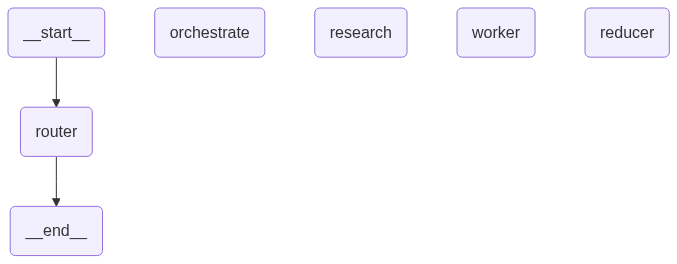

In [69]:
workflow = g.compile()
workflow

In [70]:
blog_input = "Write a blog post about OphioCordyceps fungus"
response = workflow.invoke({"topic": blog_input})

KeyError: 'references'

In [ ]:
print(f"Blog\n{response['final']}")

Blog
# Unveiling the Real-Life Zombie Fungus: The Fascinating World of Ophiocordyceps

## Introduction to *Ophiocordyceps*: Nature's Real-Life Zombie Mastermind

Long before Hollywood popularized the apocalyptic horrors of the undead in *The Last of Us* or *The Walking Dead*, Mother Nature had already perfected the art of mind control. Enter ***Ophiocordyceps***, a genus of entomopathogenic fungi that has captured the collective human imagination for its chilling, yet fascinating, life cycle. Often dubbed the "real-life zombie fungus," *Ophiocordyceps* blurs the line between science fiction and biological reality by hijacking the nervous systems of unsuspecting insects—most notably carpenter ants—transforming them into obedient, living hosts before ultimately consuming them from the inside out. 

To the casual observer, this fungal phenomenon sounds like the dark premise of a horror movie. To mycologists and evolutionary biologists, it is one of the most intricate and successful surviv